In [1]:
import pandas as pd



In [2]:
def load_csv(file):
    try:
        return pd.read_csv(
            file,
            engine="python",
            on_bad_lines="skip",
            encoding="utf-8"
        )
    except:
        return pd.read_csv(
            file,
            engine="python",
            on_bad_lines="skip",
            encoding="latin1"
        )

orders = pd.read_csv("orders_dataset.csv", engine="python")
order_items = pd.read_csv("order_items_dataset.csv", engine="python", on_bad_lines="skip")
payments = pd.read_csv("order_payments_dataset.csv", engine="python")
reviews = pd.read_csv("order_reviews_dataset.csv", engine="python")
products = pd.read_csv("products_dataset.csv", engine="python")

In [3]:
#revenue
payment_per_order = payments.groupby('order_id')['payment_value'].sum().reset_index()
#num_products
num_products = order_items.groupby('order_id')['product_id'].count().reset_index()
num_products.rename(columns={'product_id': 'num_products_sold'}, inplace=True)

#avg_price
avg_price = order_items.groupby('order_id')['price'].mean().reset_index()
avg_price.rename(columns={'price': 'avg_price'}, inplace=True)

# total_price
total_price = order_items.groupby('order_id')['price'].sum().reset_index()
total_price.rename(columns={'price': 'total_price'}, inplace=True)

In [4]:
#review
review = reviews.groupby('order_id')['review_score'].mean().reset_index()

##Merge Datasets

In [5]:
data = orders.copy()

data = data.merge(payment_per_order, on='order_id', how='left')
data = data.merge(num_products, on='order_id', how='left')
data = data.merge(avg_price, on='order_id', how='left')
data = data.merge(total_price, on='order_id', how='left')
data = data.merge(review, on='order_id', how='left')

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  object        
 8   payment_value                  99441 non-null  float64       
 9   num_products_sold              99441 non-null  float64       
 10  avg_price                      99441 non-null  float64       
 11  total_price    

##Feature Engineering

In [7]:
# conver dataes
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'], errors='coerce')

data['order_delivered_customer_date'] = pd.to_datetime(
    data['order_delivered_customer_date'], errors='coerce'
)



In [8]:
# create delivery_time
data['delivery_time'] = (
    data['order_delivered_customer_date'] - data['order_purchase_timestamp']
).dt.days


In [9]:
# create date features
data['day_of_week'] = data['order_purchase_timestamp'].dt.dayofweek
data['month'] = data['order_purchase_timestamp'].dt.month



In [10]:
# handeling missing values
data['delivery_time'] = data['delivery_time'].fillna(data['delivery_time'].median())
data['review_score'] = data['review_score'].fillna(data['review_score'].median())

data['num_products_sold'] = data['num_products_sold'].fillna(1)
data['avg_price'] = data['avg_price'].fillna(data['avg_price'].median())
data['total_price'] = data['total_price'].fillna(data['total_price'].median())
data['payment_value'] = data['payment_value'].fillna(0)


##Create the target (Revenue)

In [11]:
y = data['payment_value']

In [12]:
data.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,num_products_sold,avg_price,total_price,review_score,delivery_time,day_of_week,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,1.0,29.99,29.99,4.0,8.0,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,1.0,118.70,118.70,4.0,13.0,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,1.0,159.90,159.90,5.0,9.0,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,1.0,45.00,45.00,5.0,13.0,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,1.0,19.90,19.90,5.0,2.0,1,2
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,175.26,1.0,147.90,147.90,4.0,16.0,6,7
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaT,2017-05-09 00:00:00,65.95,1.0,49.90,49.90,2.0,10.0,1,4
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,75.16,1.0,59.99,59.99,5.0,9.0,1,5
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,35.95,1.0,19.90,19.90,1.0,9.0,0,1
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,169.76,1.0,149.99,149.99,5.0,18.0,5,7


In [ ]:
data .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  object        
 8   payment_value                  99441 non-null  float64       
 9   num_products_sold              99441 non-null  float64       
 10  avg_price                      99441 non-null  float64       
 11  total_price    

##Feature Selection

In [ ]:
features = [
    'num_products_sold',
    'avg_price',
    'total_price',
    'review_score',
    'delivery_time',
    'day_of_week',
    'month'
]

##Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['order_status'] = le.fit_transform(data['order_status'])

features.append('order_status')

##Prepare the model

In [ ]:
X = data[features]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Building ML Model

In [ ]:
#RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
#LinearRegression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
#GradientBoost
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [ ]:
#xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

##Building Deep learning Models

In [ ]:
#Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten

In [ ]:
#ANN


model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model_ann.compile(
    optimizer='adam',
    loss='mse'
)

model_ann.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_ann = model_ann.predict(X_test).flatten()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2486/2486 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 11995.0654
Epoch 2/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1704.7264
Epoch 3/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1363.5166
Epoch 4/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1326.2726
Epoch 5/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1326.6787
Epoch 6/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1318.6819
Epoch 7/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1316.1052
Epoch 8/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 1311.9746
Epoch 9/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1314.8707
Epoch 10/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1307.1267
Epoch 11/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1312.1829
Epoch 12/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1305.1079
Epoch 13/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1305.7808
Epoch 14/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1305.67

In [ ]:
#CNN
# reshape
X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn = X_test.reshape(-1, X_test.shape[1], 1)

model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn.compile(
    optimizer='adam',
    loss='mse'
)

model_cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_cnn = model_cnn.predict(X_test_cnn).flatten()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8263.0732 
Epoch 2/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1675.7339
Epoch 3/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1410.9771
Epoch 4/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1345.2782
Epoch 5/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1335.8933
Epoch 6/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1331.5406
Epoch 7/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1330.6715
Epoch 8/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1323.4576
Epoch 9/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1323.9696
Epoch 10/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1318.4863
Epoch 11/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1320.8820
Epoch 12/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1320.9055
Epoch 13/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1318.2223
Epoch 14/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1317.23

In [ ]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_test, y_pred):
    print(f"\n===== {name} =====")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2  :", r2_score(y_test, y_pred))

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Gradient Boosting", y_test, y_pred_gb)
evaluate("XGBoost", y_test, y_pred_xgb)
evaluate("ANN", y_test, y_pred_ann)
evaluate("CNN", y_test, y_pred_cnn)


===== Linear Regression =====
MAE : 10.086507160611685
RMSE: 39.50231115854948
R2  : 0.9674041009072574

===== Random Forest =====
MAE : 10.28822268979139
RMSE: 42.524284308525395
R2  : 0.9622260866576174

===== Gradient Boosting =====
MAE : 9.799114382980099
RMSE: 38.24233372786936
R2  : 0.9694503156225408

===== XGBoost =====
MAE : 12.609632186220269
RMSE: 78.63935537757038
R2  : 0.8708192376516803

===== ANN =====
MAE : 10.251987651316876
RMSE: 38.807013091580615
R2  : 0.9685414726959148

===== CNN =====
MAE : 10.34542328125979
RMSE: 38.910699717332754
R2  : 0.9683731430126992


##Visualization

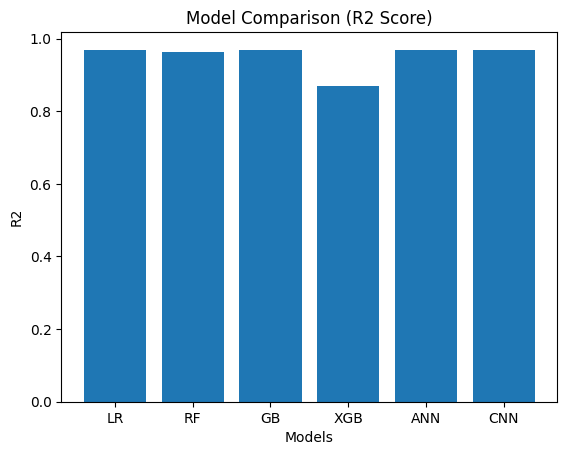

In [ ]:
import matplotlib.pyplot as plt

models = ['LR', 'RF', 'GB', 'XGB', 'ANN', 'CNN']

r2 = [0.9674, 0.9622, 0.9694, 0.8708, 0.9685, 0.9683]

plt.figure()
plt.bar(models, r2)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2")
plt.show()

##Sentiment Model

In [13]:
#review_score feature Handeling
data['review_score'] = data['review_score'].fillna(data['review_score'].median())

In [16]:
#Build Sentiment Model

text_data = reviews[['order_id', 'review_comment_message']].copy()

In [17]:
#Delete missing values
text_data = text_data.dropna(subset=['review_comment_message'])

In [18]:
#clean the data
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

text_data['clean_review'] = text_data['review_comment_message'].apply(clean_text)

###Build the sentiment Model

In [22]:

!pip install vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00


In [23]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [24]:
analyzer = SentimentIntensityAnalyzer()

text_data['sentiment_score'] = text_data['clean_review'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

In [25]:
#Aggregate based on order id
sentiment_per_order = text_data.groupby('order_id')['sentiment_score'].mean().reset_index()

In [26]:
#Merge with data
data = data.merge(sentiment_per_order, on='order_id', how='left')

In [27]:
#Missing vlaue handeling
data['sentiment_score'] = data['sentiment_score'].fillna(0)

In [28]:
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_value', 'num_products_sold', 'avg_price', 'total_price',
       'review_score', 'delivery_time', 'day_of_week', 'month',
       'sentiment_score'],
      dtype='object')

In [29]:
data[['order_id', 'sentiment_score']].head(10)

,order_id,sentiment_score
0,e481f51cbdc54678b7cc49136f2d6af7,-0.296
1,53cdb2fc8bc7dce0b6741e2150273451,0.000
2,47770eb9100c2d0c44946d9cf07ec65d,0.000
3,949d5b44dbf5de918fe9c16f97b45f8a,-0.296
4,ad21c59c0840e6cb83a9ceb5573f8159,0.000
5,a4591c265e18cb1dcee52889e2d8acc3,0.000
6,136cce7faa42fdb2cefd53fdc79a6098,0.000
7,6514b8ad8028c9f2cc2374ded245783f,0.000
8,76c6e866289321a7c93b82b54852dc33,0.000
9,e69bfb5eb88e0ed6a785585b27e16dbf,0.000


In [30]:
data['sentiment_score'].describe()

,sentiment_score
count,99441.000000
mean,-0.028238
std,0.149691
min,-0.898200
25%,0.000000
50%,0.000000
75%,0.000000
max,0.913600


In [33]:
#create sentiment_label
def label_sentiment(score):
    if score >= 0:
        return 1   # Positive
    else:
        return 0   # Negative

text_data['sentiment_label'] = text_data['sentiment_score'].apply(label_sentiment)

In [35]:
sentiment_label_per_order = text_data.groupby('order_id')['sentiment_label'].mean().reset_index()

In [36]:
#Merge to data
data = data.merge(sentiment_label_per_order, on='order_id', how='left')

data['sentiment_label'] = data['sentiment_label'].fillna(0)

In [37]:
#create review_length feature
text_data['review_length'] = text_data['clean_review'].apply(lambda x: len(x.split()))

In [39]:
#create num of positive words
text_data['is_positive'] = text_data['sentiment_score'].apply(lambda x: 1 if x > 0 else 0)

In [40]:
#Aggregate the new features
text_features = text_data.groupby('order_id').agg({
    'review_length': 'mean',
    'is_positive': 'mean'
}).reset_index()

In [41]:
#merge with data
data = data.merge(text_features, on='order_id', how='left')

data[['review_length', 'is_positive']] = data[['review_length', 'is_positive']].fillna(0)

In [60]:
text_features_list = [
    'sentiment_score',
    'sentiment_label',
    'review_score',
    'review_length',
    'is_positive'
]

##Build TF-IDF

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [34]:

tfidf = TfidfVectorizer(max_features=5000)

X_text = tfidf.fit_transform(text_data['clean_review'])
y_sent = text_data['sentiment_label']

##Prepare the Model


In [61]:
X = data[text_features_list]

y = data['payment_value']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##ML Models

In [64]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [65]:
#Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [66]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [67]:
#XG Boost
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

##Deep Learning

In [68]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [69]:
#ANN Model
model_ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)
])

model_ann.compile(optimizer='adam', loss='mse')

model_ann.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

y_pred_ann = model_ann.predict(X_test).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense

In [71]:
#Build CNN Model

# reshape
X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn = X_test.reshape(-1, X_test.shape[1], 1)

model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train.shape[1],1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')

model_cnn.fit(X_train_cnn, y_train, epochs=20, batch_size=32, verbose=0)

y_pred_cnn = model_cnn.predict(X_test_cnn).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


##Evaluation

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

# ML
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("XGBoost", y_test, y_pred_xgb)

# DL
evaluate_model("ANN", y_test, y_pred_ann)
evaluate_model("CNN", y_test, y_pred_cnn)

# Table of result
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])

print(results_df)

               Model         MAE        RMSE        R2
0  Linear Regression  109.655793  218.140054  0.005995
1      Random Forest  110.802900  219.973512 -0.010785
2  Gradient Boosting  109.764802  218.379147  0.003814
3            XGBoost  110.290345  219.265360 -0.004287
4                ANN  109.097306  218.124563  0.006136
5                CNN  108.980784  218.060633  0.006718


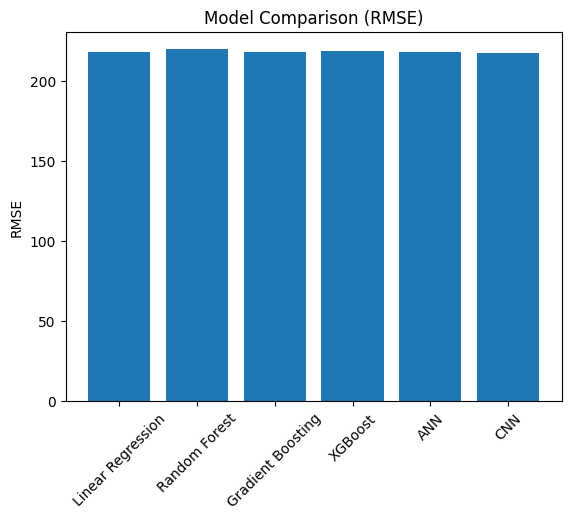

In [73]:
#RMSE coprassion
plt.figure()
plt.bar(results_df['Model'], results_df['RMSE'])
plt.xticks(rotation=45)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()


##Hybrid Model

In [ ]:
#Hybrid Model
